<a href="https://colab.research.google.com/github/DEV-MIPH/ElLocohLector/blob/main/3_Notebook_Limpieza.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **LIMPIEZA DE DATOS CON PYTHON**
---

Importamos las librerias que usaremos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import  SimpleImputer

Descripción de cada columna:
- PassengerId: Número de pasajero
- Survived : Sobrevivió o no? 1 - 0
- Pclass : En que clase viajaba
- Name: Nombre del pasajero
- Sex: Es hombre o mujer?
- Age: Edad del pasajero
- SibSp: Número de hermanos/cónyuges a bordo del Titanic
- Parch: Número de padres/hijos a bordo del Titanic
- Ticket: Número de boleto
- Fare: Tarifa del pasajero
- Cabin: Número de cabina donde se alojaba cada pasajero
- Embarked: Puerto de embarque

Cargamos los datos


In [ ]:
## Cargamos dataset de pasajeros del titanic
data=pd.read_csv('train.csv')

Recordemos algunos métodos útiles de los dataframe de pandas

In [ ]:
## visualizamos los primeros 5 registros o filas del dataset
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Para ver una información general sobre los atributos del dataframe

In [ ]:
## Visualizamos las columnas (variables) del dataset, cantidad de valores no nulos y tipo de dato
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Para obtener una descripcion estadística de las columnas numéricas

In [ ]:
##Mostramos estadística descriptiva de las variables numéricas
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Para obtener una descripción de las categóricas

In [ ]:
##Mostramos estadística descriptiva de las variables categóricas
data.describe(include=['O'])
#data.describe(include=object)

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


Para ver el tamaño del dataset

In [ ]:
##Mostramos cantidad de filas y columnas del dataset
data.shape

(891, 12)

Para cambiar el tipo de dato de una columna

In [ ]:
## Se cambia el tipo de dato de la columna Pclass de numérico a object
data['Pclass']=data['Pclass'].astype(str)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(4), object(6)
memory usage: 83.7+ KB


In [ ]:
## Se cambia el tipo de dato de la columna Pclass de object a entero
data['Pclass']=data['Pclass'].astype(int)
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## **COMPROBACIÓN DE OUTLIERS**

De forma visual

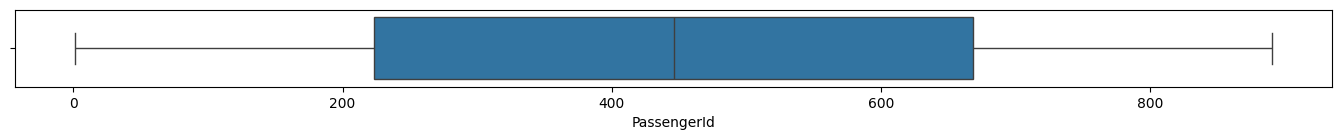

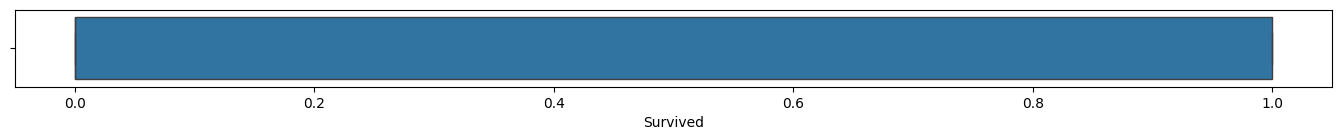

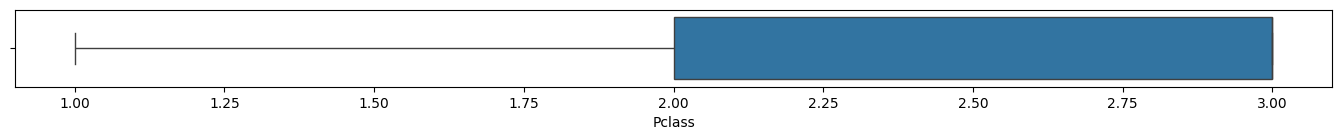

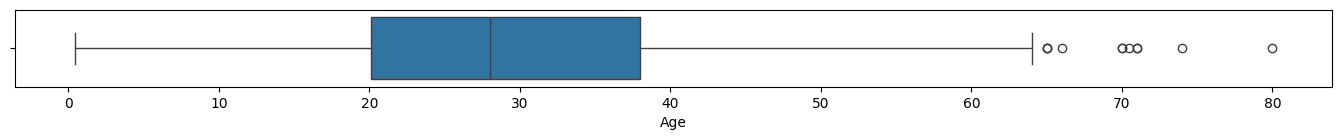

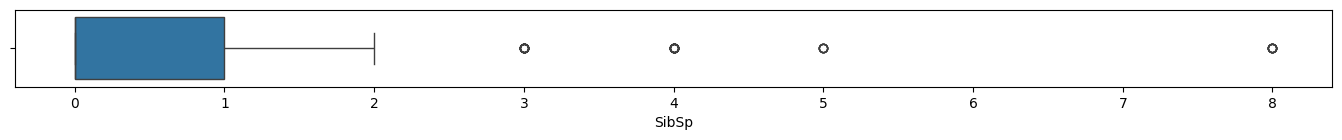

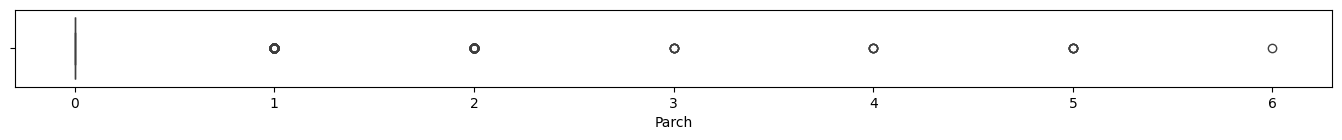

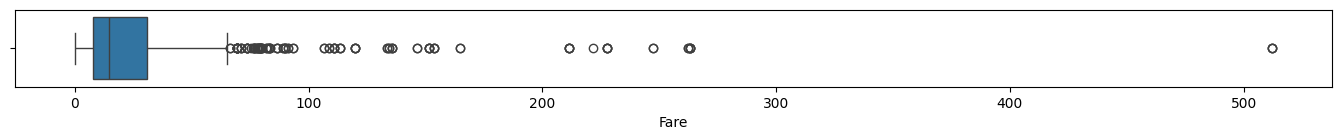

In [ ]:
## Creamos diagramas de caja para las variables numéricas para determinar outliers
num_cols=data.select_dtypes(include='number').columns
for col in num_cols:
  plt.figure(figsize=(17,1))
  sns.boxplot(data=data[num_cols], x=col)

Numéricamente

In [ ]:
## El Rango Intercuartílico (IQR) es una técnica robusta para detectar valores extremos
# Nº de Outliers usando rango IQR
outliers={}

for col in num_cols:
  Q1 = np.percentile(data[col], 25)
  Q3 = np.percentile(data[col], 75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers[col]= (data[col] > upper_bound).sum() + (data[col]< lower_bound).sum()

print(outliers)

{'PassengerId': np.int64(0), 'Survived': np.int64(0), 'Pclass': np.int64(0), 'Age': np.int64(0), 'SibSp': np.int64(46), 'Parch': np.int64(213), 'Fare': np.int64(116)}


In [ ]:
##La regla de las tres desviaciones estándar establece que los valores que están a más de tres desviaciones estándar
## por encima o por debajo de la media se consideran outliers.
#Nº de Outliers usando 3 std
outliers={}
for col in num_cols:
  mean=data[col].mean()
  std=data[col].std()

  outliers[col] = (data[col] > (mean + 3 *std)).sum() + (data[col] < (mean - 3 *std)).sum()

print(outliers)

{'PassengerId': np.int64(0), 'Survived': np.int64(0), 'Pclass': np.int64(0), 'Age': np.int64(2), 'SibSp': np.int64(30), 'Parch': np.int64(15), 'Fare': np.int64(20)}


<Axes: xlabel='Fare', ylabel='Count'>

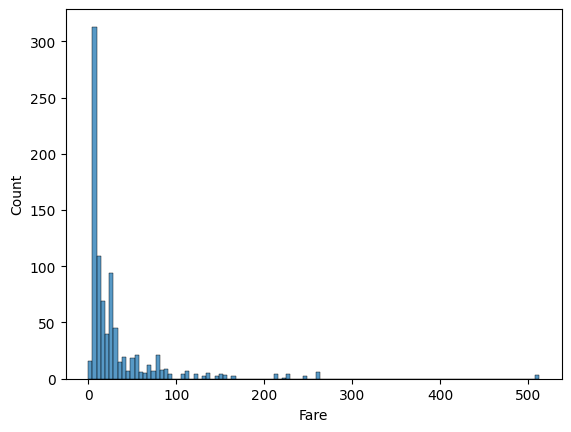

In [ ]:
sns.histplot(data['Fare'])

Veamos ahora los diferentes métodos de trabajar con nulos

In [ ]:
##Buscamos la cantidad de nulos para las diferentes variables
data.isna().sum()#/len(data)

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Eliminando los nulos

In [ ]:
##Elimina columna Cabin
data.drop('Cabin',axis=1,inplace=True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


Imputando valores

<Axes: xlabel='Age', ylabel='Count'>

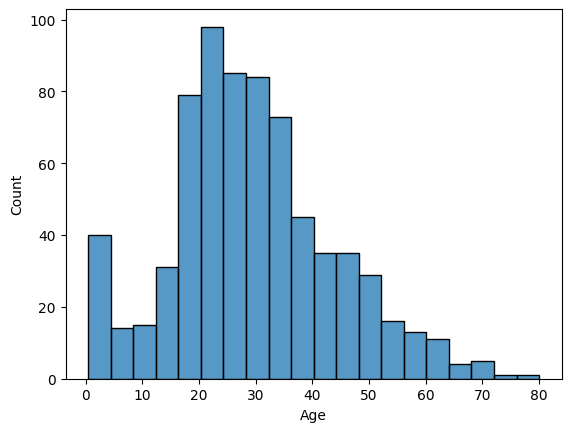

In [ ]:
sns.histplot(data['Age'])

In [ ]:
## Imputación de nulos en Edad con la mediana
impute=SimpleImputer(strategy='median')
print('Mediana inicial: ', data['Age'].median())
salida=impute.fit_transform(data[['Age']])
data['Age'] = salida #Actualizar la columna 'Age' en el DataFrame original
print('\nNulos en los nuevos datos: ',data['Age'].isna().sum())
print('\nMediana nuevos datos: ',data['Age'].median())

Mediana inicial:  28.0

Nulos en los nuevos datos:  0

Mediana nuevos datos:  28.0


Usando una constante(Por ejemplo para columnas categóricas)

In [ ]:
data.Embarked.value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [ ]:
## Imputación de valores nulos en el puerto de embarque con una constante
impute=SimpleImputer(strategy='constant',fill_value='S')
print('Recuento inicial: ', data['Embarked'].value_counts())
salida=impute.fit_transform(data[['Embarked']])
data['Embarked'] = salida.flatten() ##Actualizar la columna 'Embarked' en el DataFrame original
print('Nulos en los nuevos datos: ',data['Embarked'].isna().sum())
print('Recuento nuevos datos: ',data['Embarked'].value_counts())

Recuento inicial:  Embarked
S    644
C    168
Q     77
Name: count, dtype: int64
Nulos en los nuevos datos:  0
Recuento nuevos datos:  Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


Comprender las variables

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [ ]:
## Mostramos las variables categóricas y cuántas veces aparece cada categoría
cat_cols=data.select_dtypes(include='O').columns

for c in cat_cols:
  print('\nColumna :',c)
  print(data[c].value_counts())


Columna : Name
Name
Dooley, Mr. Patrick                                    1
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
                                                      ..
Hewlett, Mrs. (Mary D Kingcome)                        1
Vestrom, Miss. Hulda Amanda Adolfina                   1
Andersson, Mr. Anders Johan                            1
Saundercock, Mr. William Henry                         1
Bonnell, Miss. Elizabeth                               1
Name: count, Length: 891, dtype: int64

Columna : Sex
Sex
male      577
female    314
Name: count, dtype: int64

Columna : Ticket
Ticket
347082              7
1601                7
CA. 2343            7
3101295             6
CA 2144             6
                   ..
PC 17590            1
17463               1
330877              1
373450           

### Matriz de correlación

<Axes: >

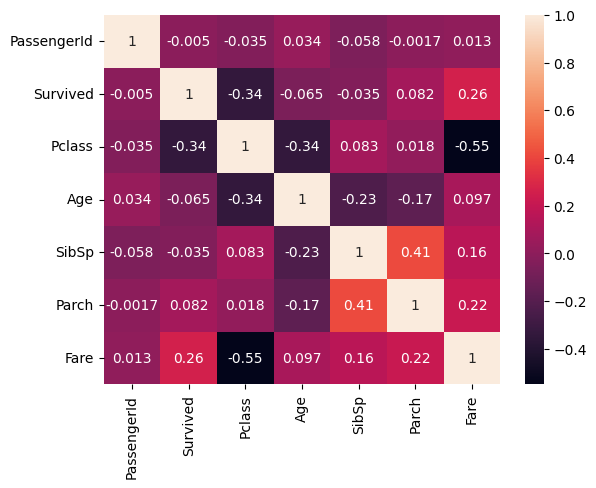

In [ ]:
num_cols=data.select_dtypes(include='number').columns
matriz=data[num_cols].corr()
sns.heatmap(matriz,annot=True)

### DESBALANCEO EN LA VARIABLE OBJETIVO

In [ ]:
data.Survived.value_counts() / len(data)

,count
Survived,
0,0.616162
1,0.383838


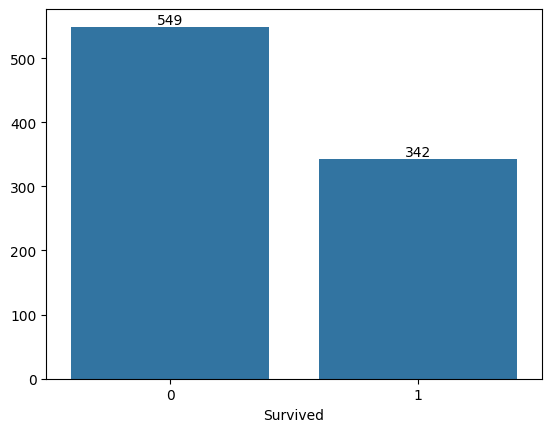

In [ ]:
ax = sns.barplot(x=data['Survived'].value_counts().index, y=data['Survived'].value_counts().values)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')


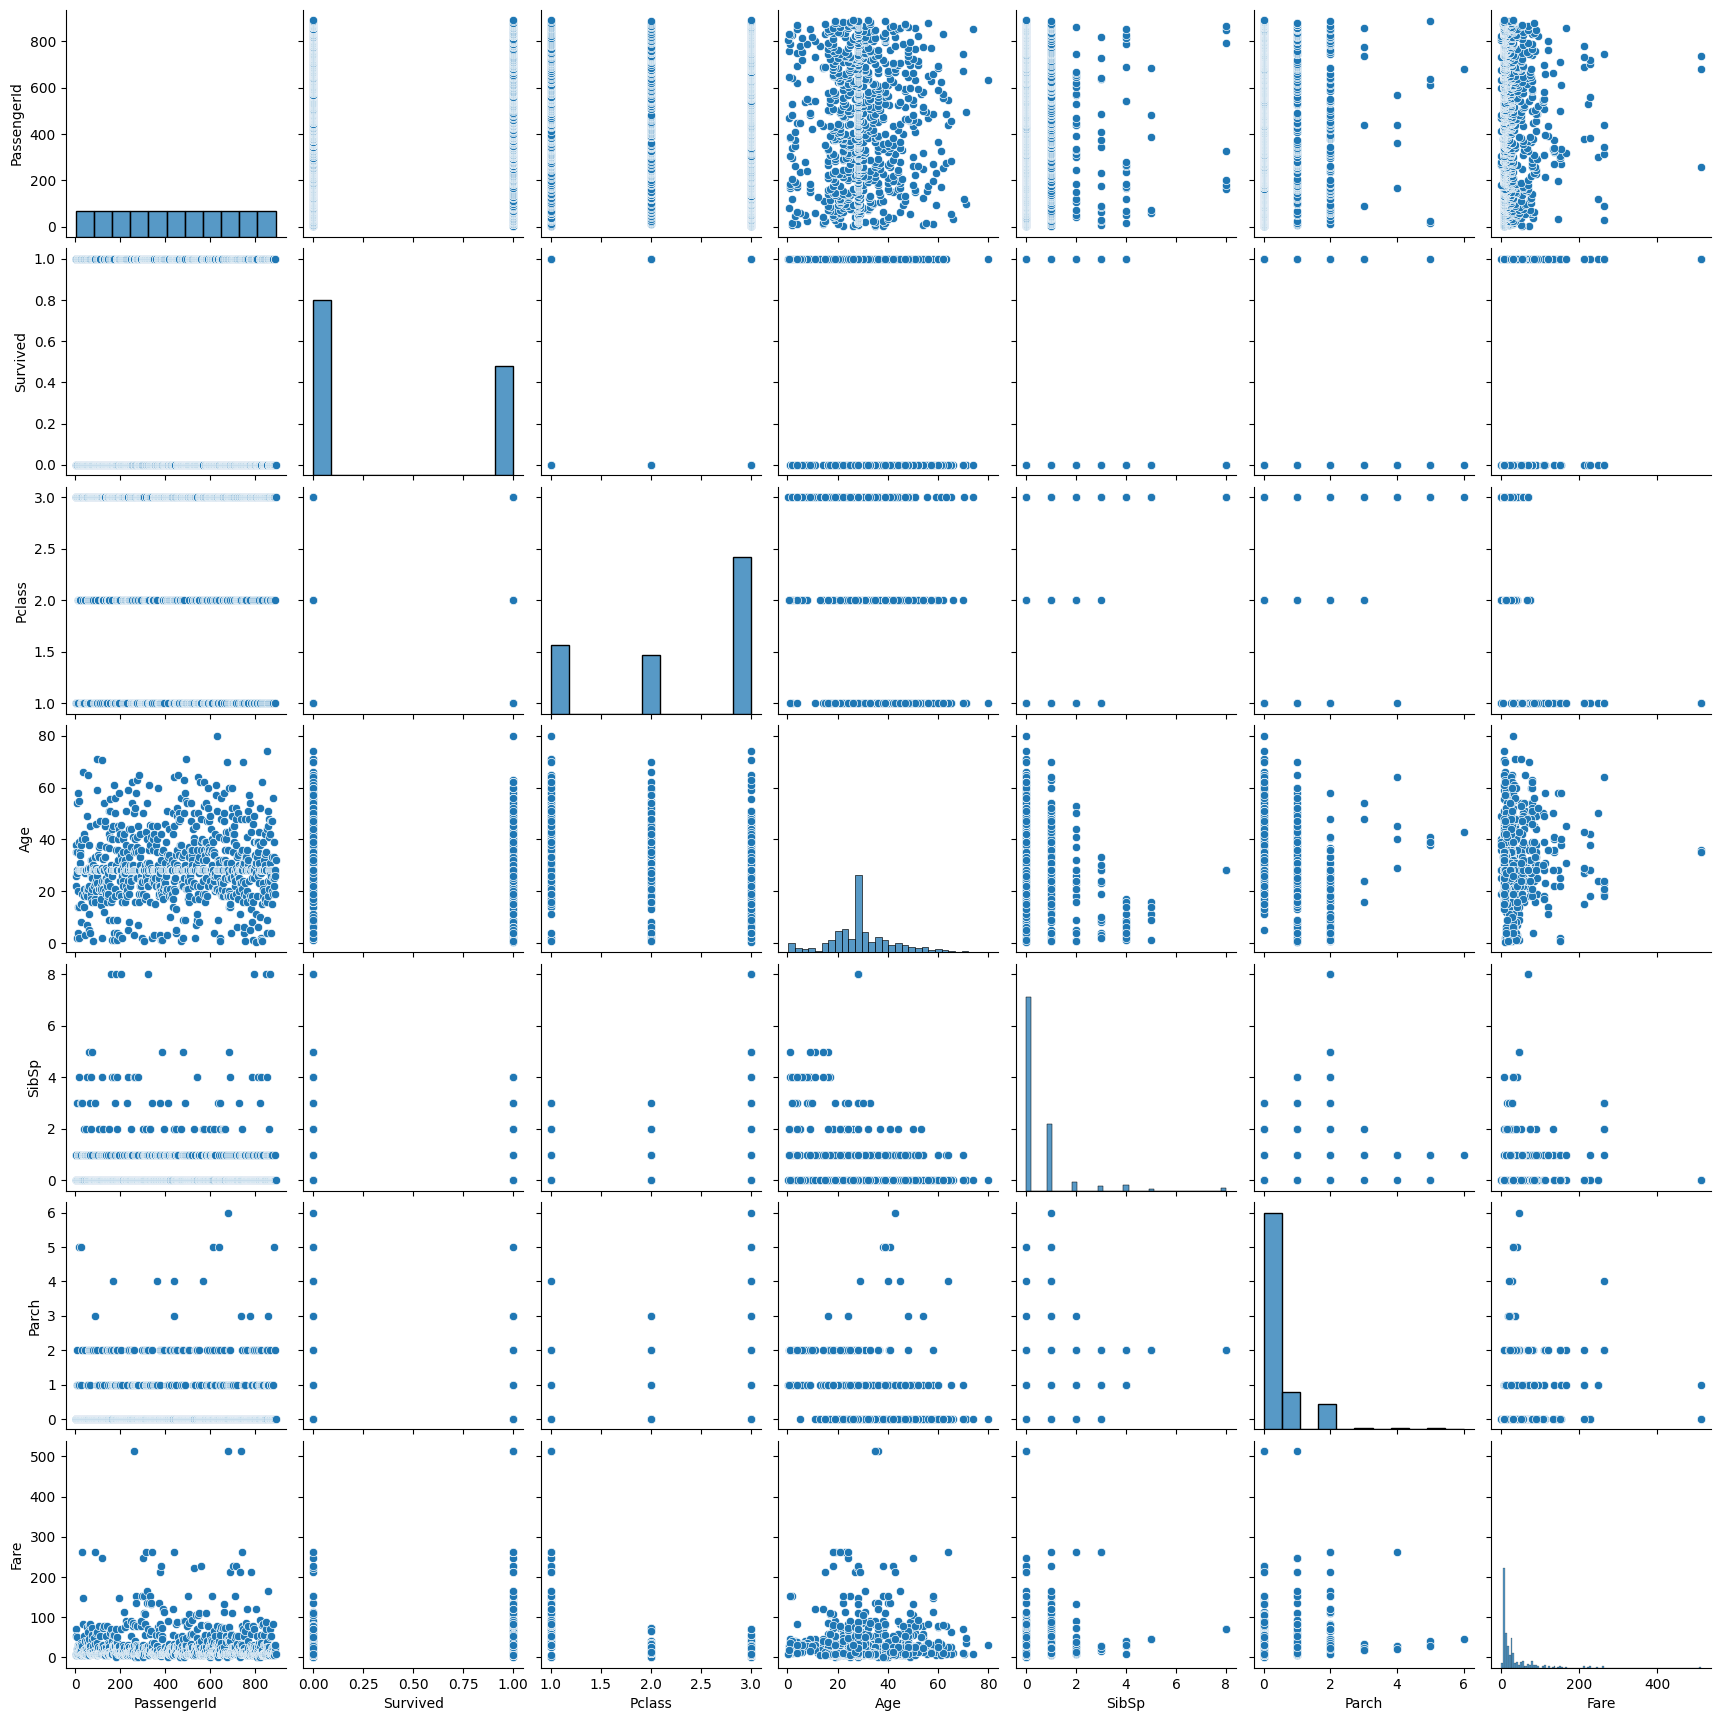

In [ ]:
##Creamos una matriz de diagramas de dispersión y distribuciones
#para entender rápidamente las relaciones entre las variables del dataset
sns.pairplot(data)